# Ch16. 강화학습

[16.1] 이론적 구성
[16.1.1] 일반적인 프레임워크
- 핵심 도구: 마르코프 의사결정 과정(MDP: Markov Decision Process)
- MDP: 에이전트(ex. 트레이더 or 포트폴리오 매니저) & 환경(ex. 금융 시장) 간의 상호작용을 포함함
- 에이전트: 환경의 상태를 바꿀 수 있는 행동 수행 &  각 행동에 대해 보상(마이너스도 가능)을 받음

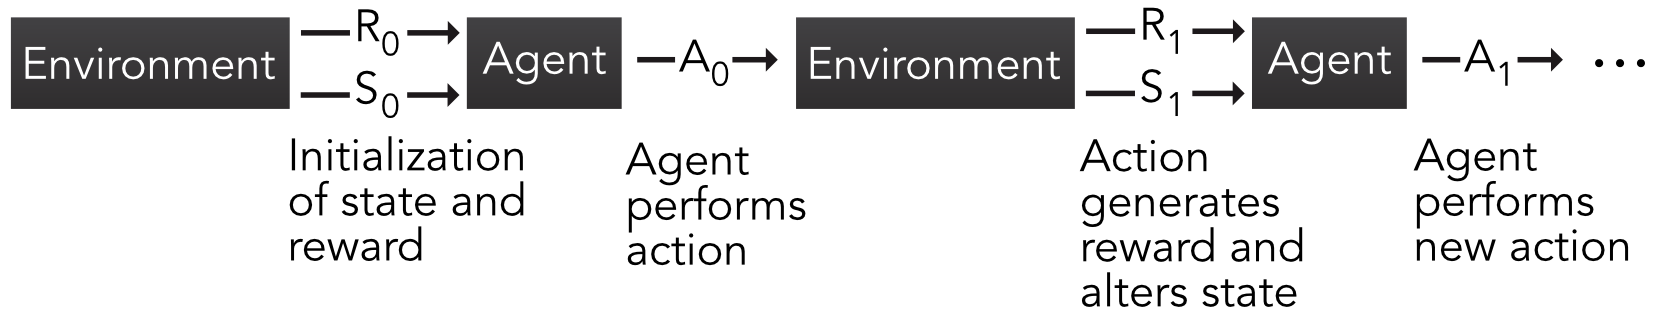

- 환경상태($S_0$) & 보상 ($R_0$)에 대해 초기화된 값이 주어지면 에이전트는 행동을 수행함 
- 보상 $R_1$ & 미래 환경 상태 $S_1$ 생성됨 => 이를 기반으로 에이전트는 새로운 행동 수행 => 시퀀스 계속됨
- 상태, 행동, 보상의 집합이 유한할 때 MDP를 논리적으로 유한하다고 표현함 ~ 금융 프레임워크에서는 다소 비현실적임
- 전이 확률(transition probability): $p(s', r|s,a)=\mathbb{P}[S_t=s',R_t=r | S_{t-1}=s,A_{t-1}=a]$ 
$\\ \rarr$ t-1 시점에 상태 s + 행동 a 가 조건부인 상황에서, t 시점에 s' + 보상 r 로 도달할 확률
- 상태 & 행동에 대한 유한 집합: $\mathcal{S}$, $\mathcal{A}$
- sometime, 위 확률은 다음과 같은 분해로 표현됨: 보상 집합에 대한 평균값
$\\ \sum_{r}rp(s',r|s,a)=P^a_{ss'}R^a_{ss'}\ :\text{기댓값},\\
P^a_{ss'}=\mathbb{P}[S_t=s'|S_{t-1}=s,\ A_{t-1}=a],\ and\\
R^a_{ss'}=\mathbb{E}[R_t|]$
- 에이전트의 목표: 일련의 보상에 대한 함수 최대화 ~ $G_t=\sum_{k=0}^T\gamma^kR_{t+k+1} \nonumber\\=R_{t+1} +\gamma G_{t+1}$
- $\gamma$: 할인 계수 ~ 보상의 할인 버전
- $\gamma <1$ & 보상 한정 => 수렴이 보장됨
- T가 유한한 경우: 에피소드적 / o/w: 연속적

- 강화학습에서 최적화/학습돼야 하는 중요 미지수: 에이전트의 행동을 유도하는 정책 $\pi$
$\\ \pi(a,s)=\mathbb{P}[A_t=a|S_t=s]$ ~ 행동이 무작위성의 영향을 받음
- 최상의 정책을 결정하기 위한 핵심 지표: 가치 함수 ~ $v_{\pi}(s)=\mathbb{E}_{\pi}[G_t|S_t=s]$: 정책 $\pi$가 시행될 떄 평균이 취해짐
$\\ \rarr$ 시장 환경이 s인 상태에서 에이전트가 $\pi$에 따라 행동 했을 떄의 평균 이익
- 행동-가치 함수($\q_{\pi}$): 상태뿐만 아니라 취한 행동에 대해서도 조건부
$\\ q_{\pi}(s,a)=\mathbb{E}_{\pi}[G_t|S_t=s, A_t=a]$: 상태와 행동이 고정됐을 때의 평균 이득 제공
- 현재 상태를 알고 있는 경우 한 가지 확실한 선택: $q_{\pi}(s,\dot)$가 가장 높은 행동 선택하기
- 가치함수 $\v_{\pi}(s)=\sum_{a}\pi(a,s)q_{\pi}(s,a)$
- 최적: $v_{*}(s)=max_{\pi}v_{\pi}(s),\ \forall{s}\in S,\ q_{*}(s,a)=max_{\pi}q_{\pi}(s,a),\ \forall{(s,a)}\in S\times A$

[16.1.2] Q-러닝
$\\ q_{\pi}(s,a)=\mathbb{E}_{\pi}[G_t|S_t=s, A_t=a]\\
=\mathbb{E}_{\pi}[R_{t+1}+\gamma G_{t+1}|S_t=s, A_t=a]$
$\\ p(s',r|s,a)$의 인자인 s' 및 r에 대한 합은 무작위 쌍 $(S_{t+1},R_{t+1})$의 분포에 액세스 부여 
$\\ \therefore \ \mathbb{E}_{\pi}[R_{t+1}|=S_t=s,A_t=a]$
$\\ \therefore q_\pi(s,a) =\sum_{a',r, s'}\pi(a',s')p(s',r|s,a)[ r+\gamma \mathbb{E}_\pi[ G_{t+1}|S_t=s',A_t=a']] \nonumber \\
=\sum_{a',r,s'}\pi(a',s')p(s',r|s,a)[ r+\gamma q_\pi(s',a')]$

$q_*=\underset{\pi}{\max} \, q_\pi(s,a):\\
q_*(s,a) = \underset{a'}{\max} \sum_{r,s'}p(s',r|s,a) [ r+\gamma q_*(s',a')], \\
= \mathbb{E}_{\pi^*}[r|s,a]+ \gamma \, \sum_{r,s'}p(s',r|s,a) (\underset{a'}{\max}  q_*(s',a'))$
- 하나의 최적 정책은 주어진 상태 s와 가능한 모든 행동 a에 대해 $q_{\pi}(s,a)$를 최대화 함 ~ 강화학습의 초석 알고리듬인 Q-러닝의 핵심

(\*) 모든 상태 s와 행동 a에 대해 값 Q(s,a)를 초기화 함
- 각 에피소드에 대해 다음 수행 ~ QL:
0. 상태 $S_0$을 초기화하고 에프소드가 끝날 때까지 각 반복 i마다 초기화
1. 상태 $s_i$ 관찰
2. (Q에 따른) 행동 $a_i$ 수행
3. 보상 $r_{i+1}$을 받고 상태 $s_{i+1}$을 관찰
4. 다음과 같이 A을 업데이트: $Q_{i+1}(s_i,a_i) \longleftarrow Q_i(s_i,a_i) + \eta (\underbrace{r_{i+1}+\gamma \, \underset{a}{\max} \, Q_i(s_{i+1},a)}_{\text{echo of Bellman eq.}}-Q_i(s_i,a_i))$
- 주어진 상태 $s_i$에 대해 기대 보상 $Q_i(s_i,a_i)$를 최대화하는 행동 $a_i$ 선택
- 잠재적으로 더 높은 보상을 얻을 수 있는 행동에서 새로운 정보 수집하려면 탐험이 필요함 -> $a_i$가 무작위로 선택됨: "$\epsilon$-그리디 탐험
$\\ a_i=\ \begin{array}{c l}
\underset{a}{\text{argmax}} \ Q_i(s_i,a) & \text{ with probability } 1-\epsilon \\
\text{randomly (uniformly) over } \mathcal{A} & \text{ with probability } \epsilon
\end{array}$
- $\epsilon$의 확률로 탐색, $1-\epsilon$의 확률로 기대 보상에 대한 현재 지식 활용해 최상의 행동 선택

[16.1.3] SARSA
- Q-러닝에서 알고리듬: 최적 정책의 행동-가치 함수 찾음 => 행동을 선택하기 위해 수반되는 정책: 학습되는 정책과 다름 ~ "off-정책"
- "on-정책": 정책 $\pi$에 따라 지속적으로 행동 -> 행동-가치 함수 $q_{\pi}$의 추정 개선 ~ 대표 ex.: SARSA 기법
- $(S_t,A_t,R_{t+1},S_{t+1},A_{t+1})$ 처리 방식:
$\\ Q_{i+1}(s_i,a_i) \longleftarrow Q_i(s_i,a_i) + \eta  (r_{i+1}+\gamma \, Q_i(s_{i+1},a_{i+1})-Q_i(s_i,a_i) )$
- Q-러닝에서는 가능한 모든 행동으로부터 최선의 값이 유지 <=> SARSA: new state&action을 기반으로 로컬 포인트에서만 개선 발생
- 기대 SARSA: $Q_{i+1}(s_i,a_i) \longleftarrow Q_i(s_i,a_i) + \eta  (r_{i+1}+\gamma \, \sum_a \pi(a,s_{i+1}) Q_i(s_{i+1},a) -Q_i(s_i,a_i) )$

[16.3] 정책 경사
- 강력 트릭: 매개 변수화
- 모든 쌍 (a,s)에 대해 행동-가치 함수 계산: 매우 번거롭
- 매개 변수 집합 $\theta$ 최적화 ~ 상태 s에서 행동 a를 선택할 확률: $\pi_{\theta}(a,s)$
- $\pi_{\theta}(a,s)=\frac{e^{\theta 'h(a,s)}}{\sum_{b}e^{\theta 'h(b,s)}}$
- $\theta$ 와 같은 차원을 갖는 함수 $h(a,s)$의 출력=쌍 (a,s)를 나타내는 특성 벡터 ~ 2개의 입력 단위 + 길이 $\theta$ 의 출력 차원을 가진 간단한 신경망
- $\pi_{theta}$에 대해 요구되는 속성: 이 값이 $\theta$에 대해 미분 가능해 결국 어떤 경사 기법을 통해 $\theta$를 개선할 수 있어야 함
- 정책 경사에 대한 가장 간단: 평균 이득 $\mathbb{E}_{\theta}[G_t]$ 최대화
- 기댓값: $\theta$ 에 의존하는 특정 정책에 따라 계산됨
- 정책 경사 정리: $\nabla \mathbb{E}_{\boldsymbol{\theta}}[G_t]=\mathbb{E}_{\boldsymbol{\theta}} [G_t\frac{\nabla \pi_{\boldsymbol{\theta}}}{\pi_{\boldsymbol{\theta}}}]$
- 경사 상승에 사용 가능: $\boldsymbol{\theta} \leftarrow \boldsymbol{\theta} + \eta \nabla \mathbb{E}_{\boldsymbol{\theta}}[G_t]$

[16.3.2] 확장
- Reinforce의 인기 있는 확장 기능: 정책 경사 + Q- or v-러닝 결합한 "행위자-비평가(AC)" 방식
- 상태-값 함수 $v(\dot)$가 일부 매개 변수 벡터 $\mathbb{w}$의 미분 가능 함수여야 함(종종 신경망으로 간주됨)
$\\ \boldsymbol{\theta} \leftarrow \boldsymbol{\theta} + \eta (R_{t+1}+\gamma v(S_{t+1},\textbf{w})-v(S_t,\textbf{w}))\frac{\nabla \pi_{\boldsymbol{\theta}}}{\pi_{\boldsymbol{\theta}}}$
- $\pi=\pi_{\alpha}=f_{\alpha}$ 로 설정:
$\\ (\textbf{F1}) \quad  \alpha_{n,t}=\theta_{0,t} + \sum_{k=1}^K \theta_{t}^{(k)}x_{t,n}^{(k)}$
- 주어진 알고리듬의 업데이트 규칙의 결과를 $\theta^*$ 라고 한다면, 가장 근접한 실현 가능 벡터: $\boldsymbol{\theta}= \underset{\textbf{z} \in \Theta(\textbf{x}_t)}{\min} ||\boldsymbol{\theta}^*-\textbf{z}||^2$
- $\Theta(\textbf{x}_t)$: 실현 가능한 집합, 벡터 $\theta$의 집합 => $\alpha$: 전부 음수가 아님
$\\ (\textbf{F2}) \quad  \alpha_{n,t}=\exp (\theta_{0,t} + \sum_{k=1}^K \theta_{t}^{(k)}x_{t,n}^{(k)})$: 첫째 버전의 지수 형태
$\\ \frac{\nabla_{\boldsymbol{\theta}_t} \pi^1_{\boldsymbol{\theta}_t}}{\pi^1_{\boldsymbol{\theta}_t}}= \sum_{n=1}^N \left( \digamma \left( \textbf{1}'\textbf{X}_t\boldsymbol{\theta}_t \right) - \digamma(\textbf{x}_{t,n}\boldsymbol{\theta}_t) + \ln w_n \right) \textbf{x}_{t,n}' \\
\frac{\nabla_{\boldsymbol{\theta}_t} \pi^2_{\boldsymbol{\theta}_t}}{\pi^2_{\boldsymbol{\theta}_t}}= \sum_{n=1}^N \left( \digamma \left( \textbf{1}'e^{\textbf{X}_{t}\boldsymbol{\theta}_t} \right) - \digamma(e^{\textbf{x}_{t,n}\boldsymbol{\theta}_t}) + \ln w_n \right) e^{\textbf{x}_{t,n}\boldsymbol{\theta}_t} \textbf{x}_{t,n}'$
- 시장에서 실제 선택된 자산 비중과 모델이 선택한 자산 비중 차이 계산해서 업데이트

- Q-러닝 구현 with 시뮬레이션
- 2개의 자산: 위험 자산 + 무위험 자산(수익률 0)
- 위험 과정 수익률: $|\rho|<1$, $\epsilon$: 분산 $\sigma^2$ 백색잡음 $\rarr\ r_{t+1}=a+\rho r_t+\epsilon_{t+1}$
- 환경: 과거 수익률 $r_t$ 관찰하는 것으로만 구성됨 ~ Q함수 추정해야 하므로 이산화: $r_t<0,\ -1\ o/w\ +1$
- 행동: 위험 자산에 투자한 수량 ~ {0, 0.25, 0.5, 0.75, 1}

- ar1 = np.array([1, -rho]): statsmodels의 ArmaProcess는 다항식 형태로 입력
$\\ \rarr y_t = \rho y_{t-1} + \epsilon_t$ 식을 이항하면 $(1 - \rho L)y_t = \epsilon_t$가 되므로, 계수를 [1, $-\rho$]로 설정

In [2]:
# 시뮬레이션으로 상태 & 보상 결정, 행동: 무작위 샘플링
from statsmodels.tsa.arima_process import ArmaProcess # AR(1) 생성 위한 라이브러리
n_sample=10**5 # 생성 샘플의 개수
rho=0.8 # 자기 회귀 계수
sd=0.4 # 잡음의 표준 편차
a=0.06*(1-rho) # 스케일된 수익률 평균 # 모델의 장기 평균 설정

import numpy as np
ar1=np.array([1,-rho])
AR_object1=ArmaProcess(ar1) # AR 객체 생성
simulated_data_AR1=AR_object1.generate_sample(nsample=n_sample, scale=sd) # AR 객체로부터 생성된 샘플
returns=a/rho + simulated_data_AR1 # 평균 조정
action=np.round(np.random.uniform(size=n_sample)*4)/4 # 임의적 행동
state=np.where(returns<0,'neg','pos')
reward=returns*action

In [3]:
import pandas as pd
data_RL=pd.DataFrame([returns, action, state, reward]).T
data_RL.columns=['returns','action','state','reward']
# lag 통한 다음 상태
data_RL['new_state']=data_RL['state'].shift(-1)
# 마지막 줄의 새로운 상태 결측 제거
data_RL=data_RL.dropna(axis=0).reset_index(drop=True)
data_RL.head()

,returns,action,state,reward,new_state
0,-0.208342,0.25,neg,-0.052086,neg
1,-0.491329,1.0,neg,-0.491329,neg
2,-0.996655,0.25,neg,-0.249164,neg
3,-0.85452,0.0,neg,-0.0,neg
4,-0.928792,1.0,neg,-0.928792,neg


In [4]:
alpha=0.1 # 학습률
gamma=0.7 # 보상에 대한 할인 계수
epsilon=0.5 # 탐험률
def looping_w_counters(obj_array):
    _dict={z:i for i,z in enumerate(obj_array)}
    return _dict
s=looping_w_counters(data_RL['state'].unique()) # 상태 딕셔너리
a=looping_w_counters(data_RL['action'].unique()) # 행동 딕셔너리
fit_RL=np.zeros(shape=(len(s),len(a))) # 상태 X 행동 ~ Q(행렬) 위한 데이터 공간

In [5]:
r_final=0
# Q-러닝 루프
for z, row in data_RL.iterrows():
    act=a[row.action] # 각 인스턴스의 행동
    r=row.reward # 각 인스턴스의 보상
    s_current=s[row.state] # 각 인스턴스에서 시장 상태 (이산화)
    s_new=s[row.new_state] # 각 인스턴스에서 t+1 상태
    if np.random.uniform(size=1) < epsilon:
        best_new=a[np.random.choice(list(a.keys()))] # 탐험
    else:
        best_new=np.argmax(fit_RL[s_new,])
    r_final+=r
    fit_RL[s_current,act]+=alpha*(r+gamma*fit_RL[s_new, best_new]-fit_RL[s_current, act])

fit_RL=pd.DataFrame(fit_RL, index=s.keys(), columns=a.keys()).sort_index(axis=1)
print(fit_RL)
print(f'Reward (last iteration): {r_final}')

         0.00      0.25      0.50      0.75      1.00
neg  0.008563 -0.033782 -0.057504 -0.309468 -0.478921
pos  0.513065  0.615760  0.652009  1.061149  1.092497
Reward (last iteration): 1200.9308182228506


[16.4.2] 시장 데이터와 Q-러닝
- 하나의 특성만이 환경 상태 포착 가정
- 행동: +1(시장 매수), -1(시장 매도), 0(위험 포지션 보유 안 함)

Index(['stock_id', 'date', 'Advt_12M_Usd', 'Advt_3M_Usd', 'Advt_6M_Usd',
       'Asset_Turnover', 'Bb_Yld', 'Bv', 'Capex_Ps_Cf', 'Capex_Sales',
       'Cash_Div_Cf', 'Cash_Per_Share', 'Cf_Sales', 'Debtequity', 'Div_Yld',
       'Dps', 'Ebit_Bv', 'Ebit_Noa', 'Ebit_Oa', 'Ebit_Ta', 'Ebitda_Margin',
       'Eps', 'Eps_Basic', 'Eps_Basic_Gr', 'Eps_Contin_Oper', 'Eps_Dil', 'Ev',
       'Ev_Ebitda', 'Fa_Ci', 'Fcf', 'Fcf_Bv', 'Fcf_Ce', 'Fcf_Margin',
       'Fcf_Noa', 'Fcf_Oa', 'Fcf_Ta', 'Fcf_Tbv', 'Fcf_Toa', 'Fcf_Yld',
       'Free_Ps_Cf', 'Int_Rev', 'Interest_Expense', 'Mkt_Cap_12M_Usd',
       'Mkt_Cap_3M_Usd', 'Mkt_Cap_6M_Usd', 'Mom_11M_Usd', 'Mom_5M_Usd',
       'Mom_Sharp_11M_Usd', 'Mom_Sharp_5M_Usd', 'Nd_Ebitda', 'Net_Debt',
       'Net_Debt_Cf', 'Net_Margin', 'Netdebtyield', 'Ni', 'Ni_Avail_Margin',
       'Ni_Oa', 'Ni_Toa', 'Noa', 'Oa', 'Ocf', 'Ocf_Bv', 'Ocf_Ce', 'Ocf_Margin',
       'Ocf_Noa', 'Ocf_Oa', 'Ocf_Ta', 'Ocf_Tbv', 'Ocf_Toa', 'Op_Margin',
       'Op_Prt_Margin', 'Oper_Ps_Net_

<string>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


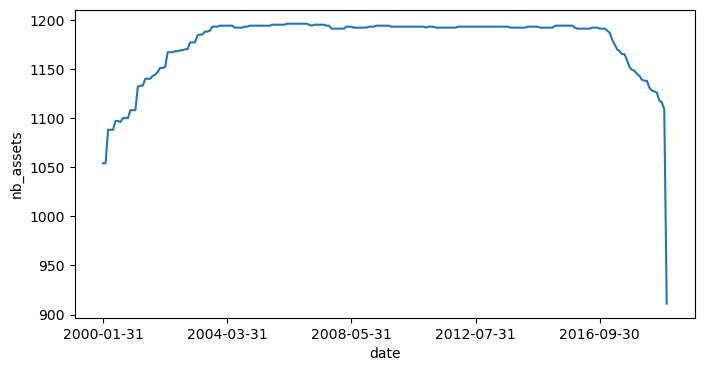

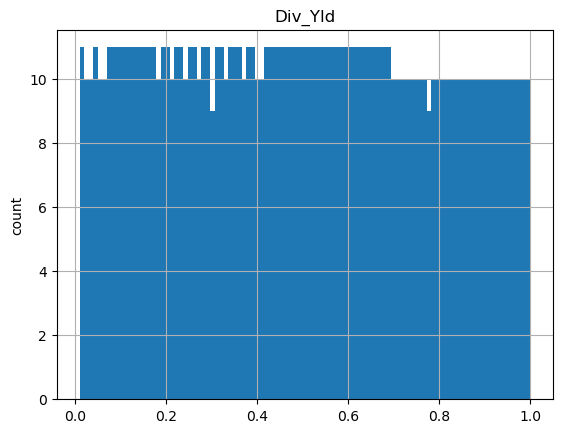

In [6]:
import import_ipynb
from Ch1 import data_ml

In [7]:
# 자산 3의 수익률
return_3=pd.Series(data_ml.loc[data_ml['stock_id']==3, 'R1M_Usd'].values)
# 자산 4의 수익률
return_4=pd.Series(data_ml.loc[data_ml['stock_id']==4, 'R1M_Usd'].values)
# 자산 3의 P/B 비율
pb_3=pd.Series(data_ml.loc[data_ml['stock_id']==3, 'Pb'].values)
# 자산 4의 P/B 비율
pb_4=pd.Series(data_ml.loc[data_ml['stock_id']==4, 'Pb'].values)
# 자산 3에 대한 (임의적) 행동
action_3=pd.Series(np.floor(np.random.uniform(size=len(pb_3))*3)-1)
# 자산 4에 대한 (임의적) 행동
action_4=pd.Series(np.floor(np.random.uniform(size=len(pb_4))*3)-1)
# 데이터셋 구축
RL_data=pd.concat([return_3, return_4, pb_3, pb_4, action_3, action_4], axis=1)
RL_data.columns=['return_3','return_4','Pb_3','Pb_4','action_3','action_4']
RL_data['action']=RL_data.action_3.astype(int).apply(str)+" "+RL_data.action_4.astype(int).apply(str) # asset 3, 4 행동 결합
# 상태 단순화
RL_data['Pb_3']=np.round(5*RL_data['Pb_3'])
RL_data['Pb_4']=np.round(5*RL_data['Pb_4'])
RL_data['state']=RL_data.Pb_3.astype(int).apply(str)+" "+RL_data.Pb_4.astype(int).apply(str) # asset 3, 4 상태 통합
# 새로운 상태 추론
RL_data['new_state']=RL_data['state'].shift(-1)
# 보상 계산
RL_data['reward']=RL_data.action_3*RL_data.return_3+RL_data.action_4*RL_data.return_4
RL_data=RL_data[['action','state','reward','new_state']].dropna(axis=0).reset_index(drop=True)
RL_data.head()

,action,state,reward,new_state
0,0 1,1 3,0.043,1 2
1,0 -1,1 2,-0.029,1 2
2,1 0,1 2,0.008,2 2
3,-1 1,2 2,0.134,2 2
4,0 1,2 2,-0.025,2 2


In [8]:
# 열: 행동, 행: 상태
alpha=0.1 # 학습률
gamma=0.7 # 보상에 대한 할인 계수
epsilon=0.1 # 탐험률

s=looping_w_counters(RL_data['state'].unique()) 
a=looping_w_counters(RL_data['action'].unique())
fit_RL2=np.zeros(shape=(len(s),len(a)))

In [11]:
r_final=0
for z, row in RL_data.iterrows():
    act=a[row.action]
    r=row.reward
    s_current=s[row.state]
    s_new=s[row.new_state]
    if np.random.uniform(size=1)<epsilon:
        best_new=a[np.random.choice(list(a.keys()))]
    else:
        best_new=np.argmax(fit_RL2[s_new,])
    r_final+=r
    fit_RL2[s_current, act]+=alpha*(r+gamma*fit_RL2[s_new,best_new]-fit_RL2[s_current,act])

fit_RL2=pd.DataFrame(fit_RL2, index=s.keys(), columns=a.keys()).sort_index(axis=1)
print(fit_RL2)
print(f'Reward (last iteration): {r_final}')

        -1 -1      -1 0      -1 1      0 -1       0 0       0 1      1 -1  \
1 3 -0.003209  0.000000  0.000000 -0.008030  0.000000  0.004266 -0.009437   
1 2  0.037476  0.018543  0.022515  0.001089  0.020805  0.008528  0.023664   
2 2  0.010683 -0.023661  0.085177  0.016138  0.005962 -0.001689  0.020249   
2 1  0.000000 -0.006465  0.000000 -0.008185  0.000000  0.013977 -0.003980   
1 1 -0.006648  0.009481  0.005965 -0.002576  0.007615  0.002894 -0.006184   
3 2 -0.002700  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3 1  0.000000  0.000000 -0.003382  0.000000  0.000000  0.000000  0.000000   
2 3  0.003816  0.000000  0.000000  0.005283  0.000000  0.000470  0.000000   
0 3  0.000000 -0.013500  0.000000  0.000000  0.000000  0.000000  0.000000   
0 1  0.000000  0.000000 -0.017700 -0.004200  0.000000 -0.003124 -0.012380   

          1 0       1 1  
1 3  0.007700 -0.006626  
1 2 -0.013658  0.056278  
2 2  0.015861  0.014534  
2 1  0.007516  0.005999  
1 1  0.017351  0.02636